# Soft-DTW Shattering Test — Fixed Point Set (`k2_m7.csv`)

This notebook:
1. **Loads** the 9-point set from `k2_m7.csv` (each point is a 2D time series, witnesses use length-7 centers).
2. **Validates** the stored witnesses under hard DTW to confirm the ground truth.
3. **Runs the Soft-DTW solver** independently on every subset to verify the set is also shattered under Soft-DTW.

Hard-DTW validation is **disabled** in the Soft-DTW solver, so acceptance is based on the loss threshold alone.

## 1 · Imports

In [15]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath("soft_dtw_solver.py")))

from soft_dtw_solver import (
    load_point_set_from_csv,
    validate_csv_witnesses,
    check_shattering,
)

import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "k2_m7.csv"

## 2 · Load point set from CSV

In [16]:
points, query_len, center_len, witnesses_csv = load_point_set_from_csv(CSV_PATH)

print(f"Points loaded    : {len(points)}")
print(f"Query length     : {query_len}  (each Qᵢ ∈ ℝ^{query_len})")
print(f"Center length    : {center_len} (witness P ∈ ℝ^{center_len})")
print(f"Stored witnesses : {len(witnesses_csv)}")
print(f"Expected 2^d     : {2 ** len(points)}")
print()
for i, p in enumerate(points):
    print(f"  Q{i} = {[round(v, 4) for v in p.tolist()]}")

Points loaded    : 9
Query length     : 2  (each Qᵢ ∈ ℝ^2)
Center length    : 7 (witness P ∈ ℝ^7)
Stored witnesses : 511
Expected 2^d     : 512

  Q0 = [-2.8861, 0.9214]
  Q1 = [-2.5739, 1.5915]
  Q2 = [-2.1322, 2.1703]
  Q3 = [-1.3631, 2.5358]
  Q4 = [1.7819, -3.0536]
  Q5 = [2.3835, -2.8099]
  Q6 = [2.6805, -2.1703]
  Q7 = [3.0688, -1.6981]
  Q8 = [-0.7082, 2.6957]


## 3 · Visualise the point set

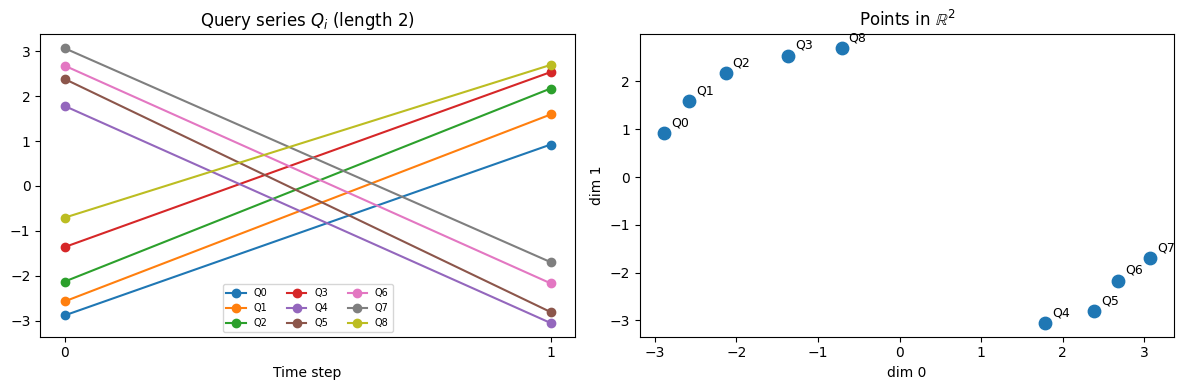

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: each Qᵢ as a length-2 time series
ax = axes[0]
for i, p in enumerate(points):
    ax.plot(p.numpy(), marker="o", label=f"Q{i}")
ax.set_title("Query series $Q_i$ (length 2)")
ax.set_xlabel("Time step")
ax.set_xticks([0, 1])
ax.legend(fontsize=7, ncol=3)

# Right: scatter of the 2-D points
ax = axes[1]
coords = [p.numpy() for p in points]
xs = [c[0] for c in coords]
ys = [c[1] for c in coords]
ax.scatter(xs, ys, s=80)
for i, (x, y) in enumerate(zip(xs, ys)):
    ax.annotate(f"Q{i}", (x, y), textcoords="offset points", xytext=(5, 5), fontsize=9)
ax.set_title("Points in $\\mathbb{R}^2$")
ax.set_xlabel("dim 0")
ax.set_ylabel("dim 1")

plt.tight_layout()
plt.show()

## 4 · Validate stored witnesses (hard DTW)

Confirms that the ground-truth witnesses in the CSV already satisfy strict separation under *hard* DTW — before we attempt anything with Soft-DTW.

In [18]:
val_results = validate_csv_witnesses(points, witnesses_csv, verbose=True)


Hard-DTW witness validation: 511/511 passed
All witnesses valid under hard DTW.


## 5 · Soft-DTW shattering check

Run `check_shattering` on the full point set **without** any warm start — the solver finds witnesses purely from scratch.  
`validation=False` means acceptance is based on **soft-DTW separation** alone (`max_in < min_out`), with no hard-DTW gate.

For each subset the first Adam run initialises $P$ as a linear interpolation of the mean of the in-set queries (upsampled to length $k$), placing the optimiser in the right numerical range from the start.  Subsequent retries use fresh random initialisations.

> ⚠️ This tests all $2^9 = 512$ subsets and may take a few minutes.


In [19]:
# ── Parameters ────────────────────────────────────────────────────────────────
GAMMA   = 1.0   # Soft-DTW smoothing  (smaller → closer to hard DTW)
EPOCHS  = 300   # gradient steps per optimisation call
RETRIES = 5     # retries per subset before declaring failure

# ── Run ───────────────────────────────────────────────────────────────────────
is_shattered, softdtw_witnesses = check_shattering(
    points,
    k=center_len,       # center length read from CSV (= 7)
    gamma=GAMMA,
    epochs=EPOCHS,
    retries=RETRIES,
    validation=False,   # no hard-DTW gate; soft-DTW separation check only
    verbose=False,      # set True for per-subset detail
    # no init_witnesses: solver finds witnesses purely from scratch
)

n_found = len(softdtw_witnesses)
n_total = 2 ** len(points)
print(f"Soft-DTW result : {'SHATTERED ✓' if is_shattered else 'NOT shattered ✗'}")
print(f"Subsets solved  : {n_found} / {n_total}")


Soft-DTW result : NOT shattered ✗
Subsets solved  : 14 / 512


## 6 · Inspect witnesses

In [20]:
from soft_dtw_solver import hard_dtw_distance, to_1d_numpy

print(f"{'Subset I':<35}  {'Delta':>10}  {'max_in':>10}  {'min_out':>10}  {'Sep?':>6}")
print("-" * 80)

for subset_key in sorted(softdtw_witnesses.keys(), key=lambda t: (len(t), t)):
    w      = softdtw_witnesses[subset_key]
    I_list = list(subset_key)
    not_I  = [j for j in range(len(points)) if j not in subset_key]

    if I_list and not_I:
        dists   = [hard_dtw_distance(w["P"], q) for q in points]
        max_in  = max(dists[i] for i in I_list)
        min_out = min(dists[j] for j in not_I)
        sep     = "✓" if max_in < min_out else "✗"
    else:
        max_in = min_out = float("nan")
        sep = "–"

    idx_str = "{" + ",".join(str(i) for i in subset_key) + "}"
    print(f"{idx_str:<35}  {w['Delta']:>10.4f}  {max_in:>10.4f}  {min_out:>10.4f}  {sep:>6}")

Subset I                                  Delta      max_in     min_out    Sep?
--------------------------------------------------------------------------------
{}                                       1.0000         nan         nan       –
{0}                                      2.6271      0.6645      3.5003       ✓
{1}                                      2.5952      1.3762      2.9774       ✓
{2}                                      2.8283      1.8200      4.0281       ✓
{3}                                      2.5470      0.7046      2.7166       ✓
{4}                                      3.1203      1.9646      4.6339       ✓
{5}                                      2.9377      1.8596      3.7971       ✓
{6}                                      2.2639      2.1519      3.1870       ✓
{7}                                      2.8163      1.3178      3.8886       ✓
{8}                                      2.3518      2.1850      6.3888       ✓
{0,1}                                  

## 7 · Plot a few witnesses

Pick a handful of subsets and visualise the Soft-DTW witness center $P$ alongside the $Q_i$.

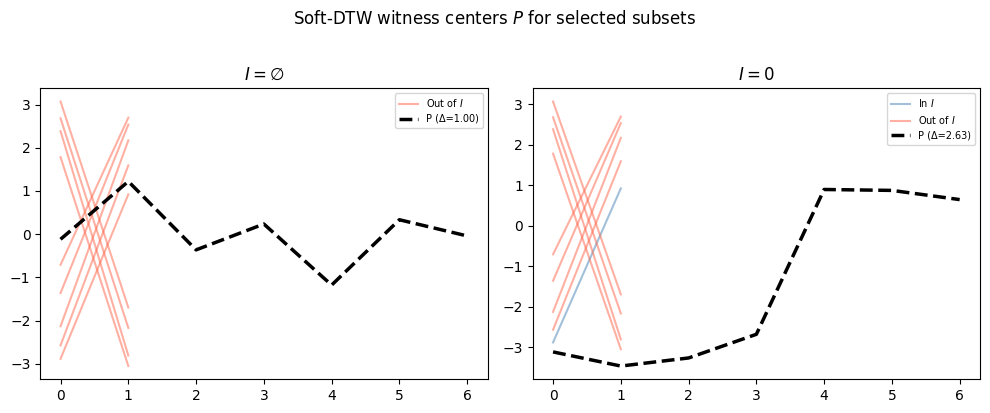

In [21]:
# Choose a few representative subsets to visualise
sample_keys = [
    (),                        # empty set
    (0,),                      # singleton
    (0, 1, 2, 3),              # size-4
    (0, 1, 2, 3, 4, 5, 6, 7, 8),  # full set
]
# Fall back gracefully if the solver didn't find a witness for a key
sample_keys = [k for k in sample_keys if k in softdtw_witnesses]

n_plots = len(sample_keys)
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4))
if n_plots == 1:
    axes = [axes]

for ax, subset_key in zip(axes, sample_keys):
    w = softdtw_witnesses[subset_key]
    P = w["P"]

    for j, q in enumerate(points):
        color = "steelblue" if j in subset_key else "tomato"
        lbl   = "In $I$" if j in subset_key else "Out of $I$"
        ax.plot(q.numpy(), color=color, alpha=0.5,
                label=lbl if j in [list(subset_key)[0] if subset_key else -1,
                                    next((x for x in range(len(points)) if x not in subset_key), -1)]
                else None)

    ax.plot(P, color="black", linewidth=2.5, linestyle="--", label=f"P (Δ={w['Delta']:.2f})")
    idx_str = "{" + ",".join(str(i) for i in subset_key) + "}" if subset_key else "∅"
    ax.set_title(f"$I = {idx_str}$")
    ax.legend(fontsize=7)

plt.suptitle("Soft-DTW witness centers $P$ for selected subsets", y=1.02)
plt.tight_layout()
plt.show()